In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:613: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [07:02<00:00,  1.99it/s]


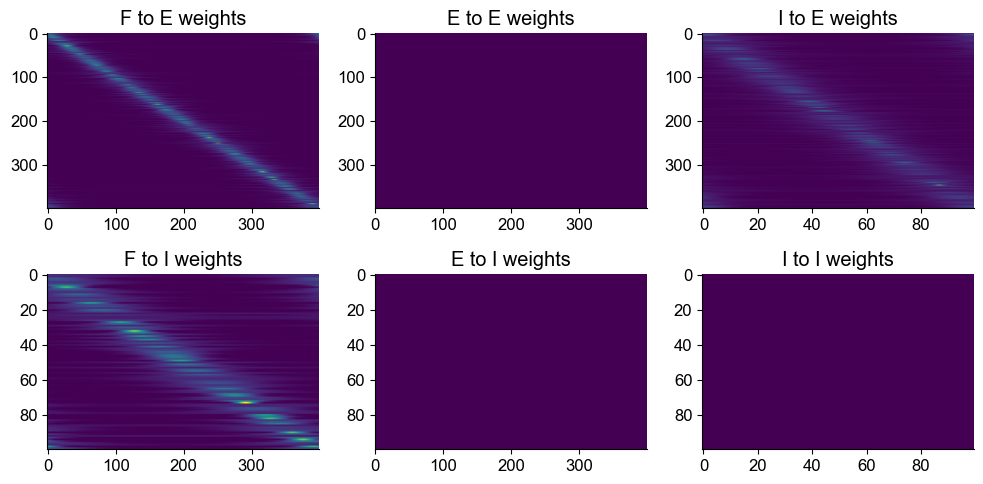

In [4]:
net = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      if_pre_run=True, n_pre_run_stimuli=300,
                      inh_scale=0.3)
net.run()

In [5]:
drift_mag, drift_rate, convergence = net.get_drift_metrics()

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:681: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


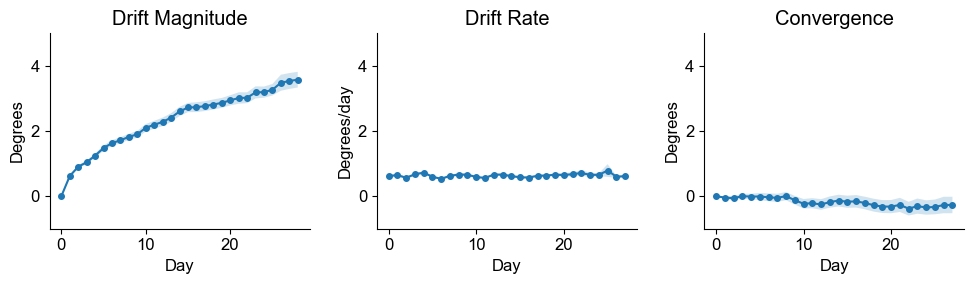

In [6]:
net.plot_drift_metrics(drift_mag, drift_rate, convergence)

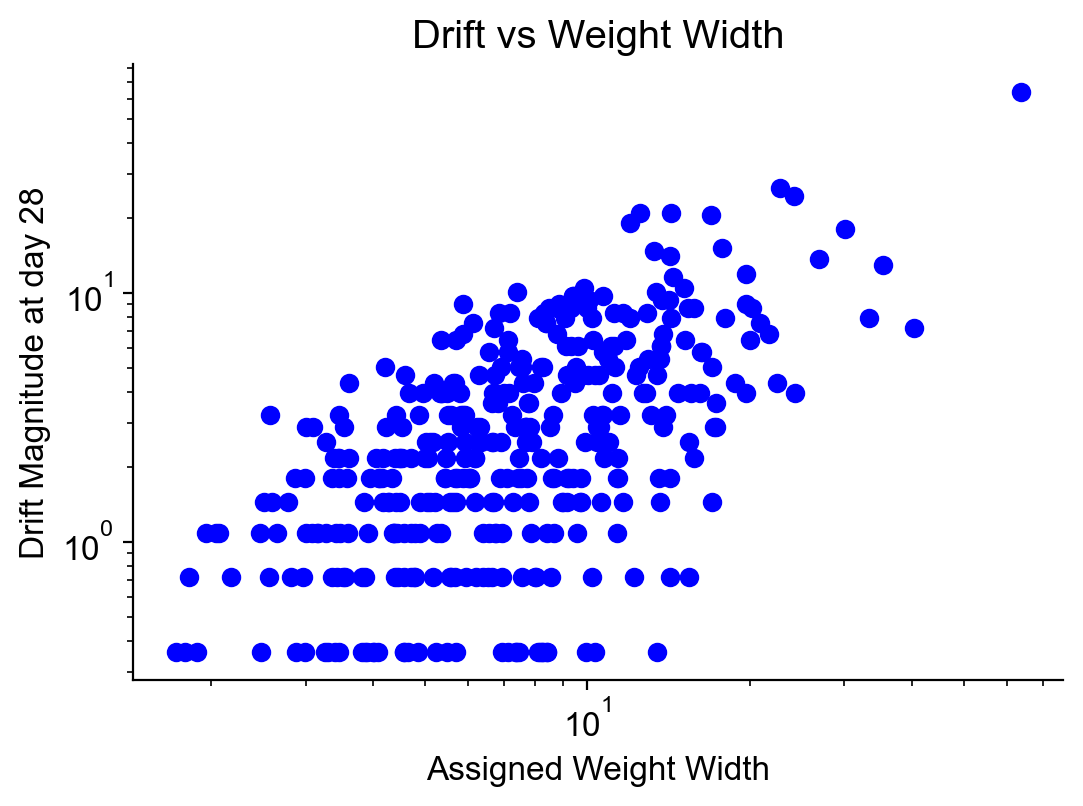

In [7]:
# Plot drift magnitude vs assigned weight width (vars_ef)

plt.figure(figsize=(6, 4), dpi=200)
plt.scatter(net.vars_ef, drift_mag[-1], color='blue')
plt.xlabel('Assigned Weight Width')
plt.ylabel('Drift Magnitude at day 28')
plt.title('Drift vs Weight Width')
plt.xscale('log')
plt.yscale('log')

plt.show()


100%|██████████| 500/500 [06:29<00:00,  1.28it/s]


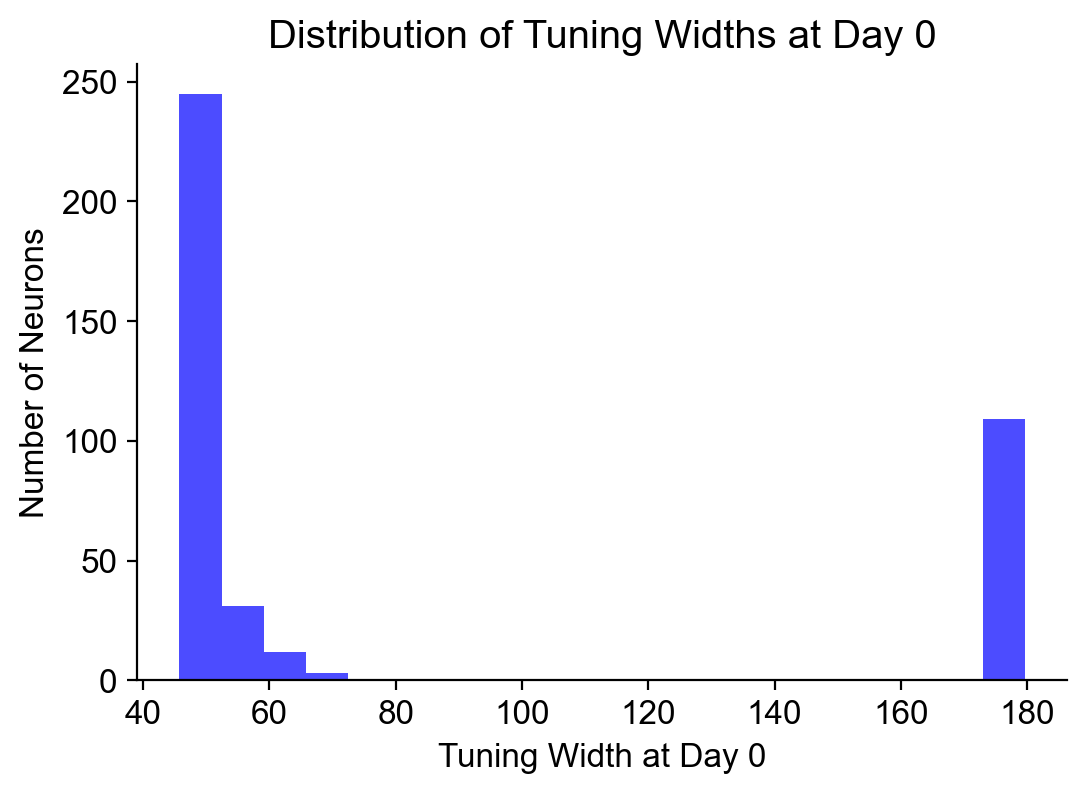

In [8]:
tuning_widths_day_0 = net.estimate_tuning_widths_at_day(0)
plt.figure(figsize=(6, 4), dpi=200)
plt.hist(tuning_widths_day_0, bins=20, color='blue', alpha=0.7)
plt.xlabel('Tuning Width at Day 0')
plt.ylabel('Number of Neurons')
plt.title('Distribution of Tuning Widths at Day 0')
plt.show()

100%|██████████| 500/500 [06:34<00:00,  1.27it/s] 
/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:570: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  


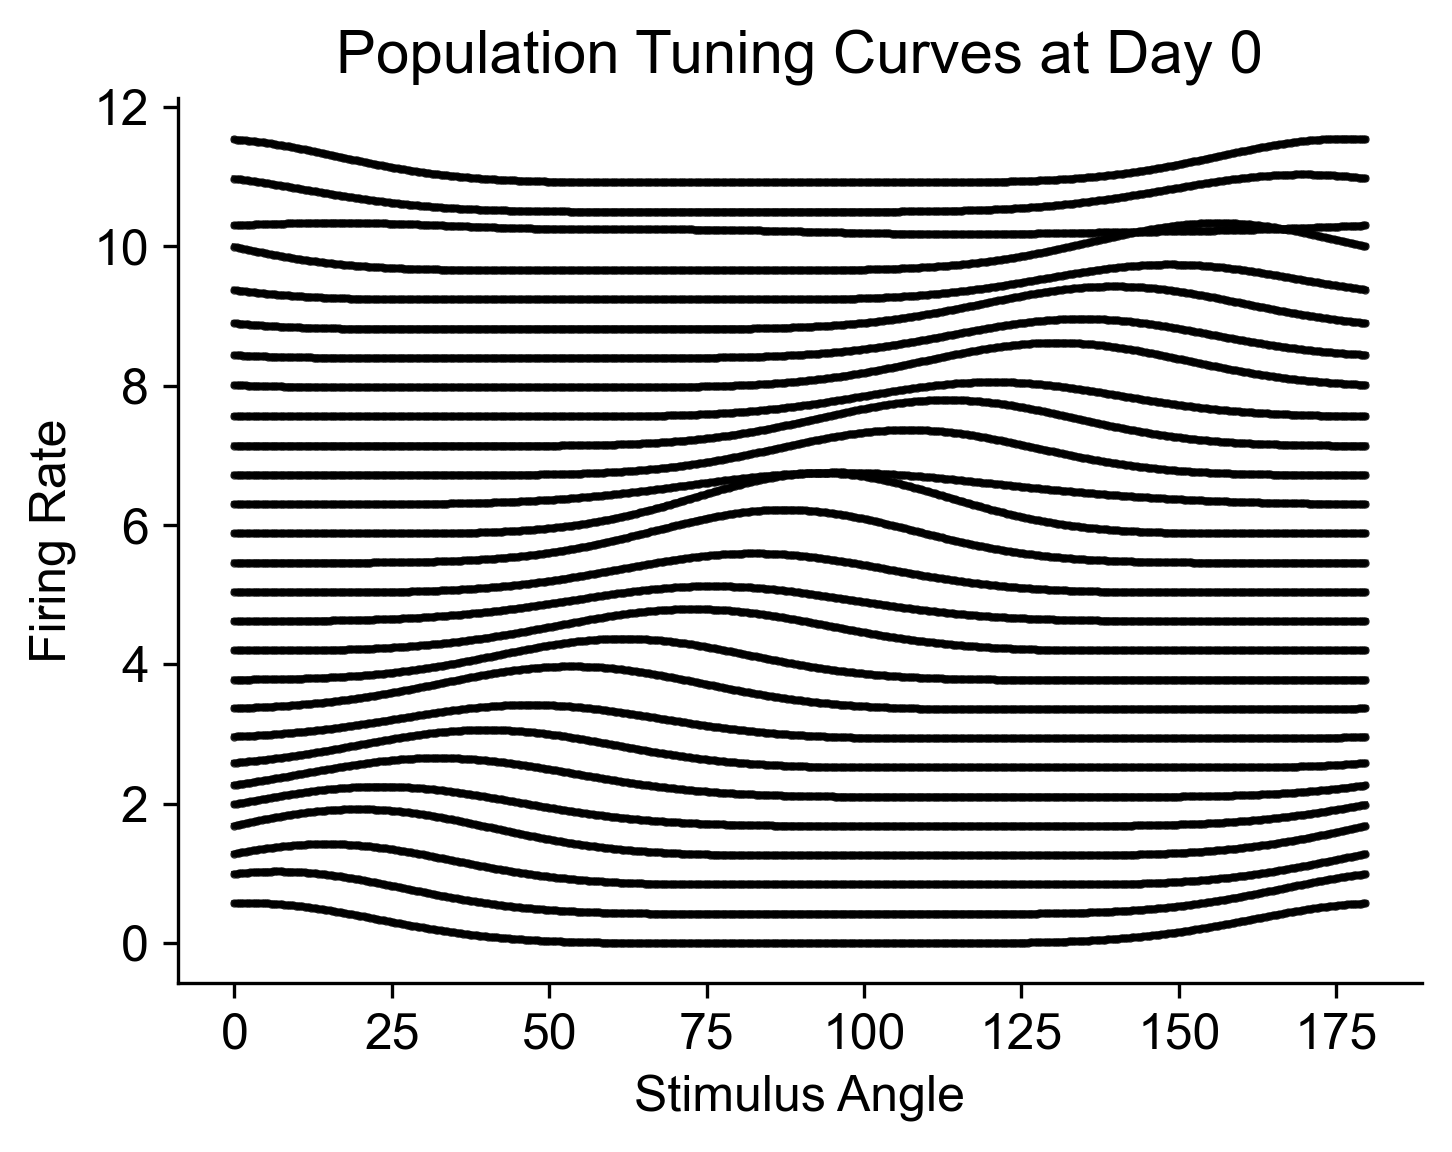

In [9]:
net.plot_population_tuning_curves(0)

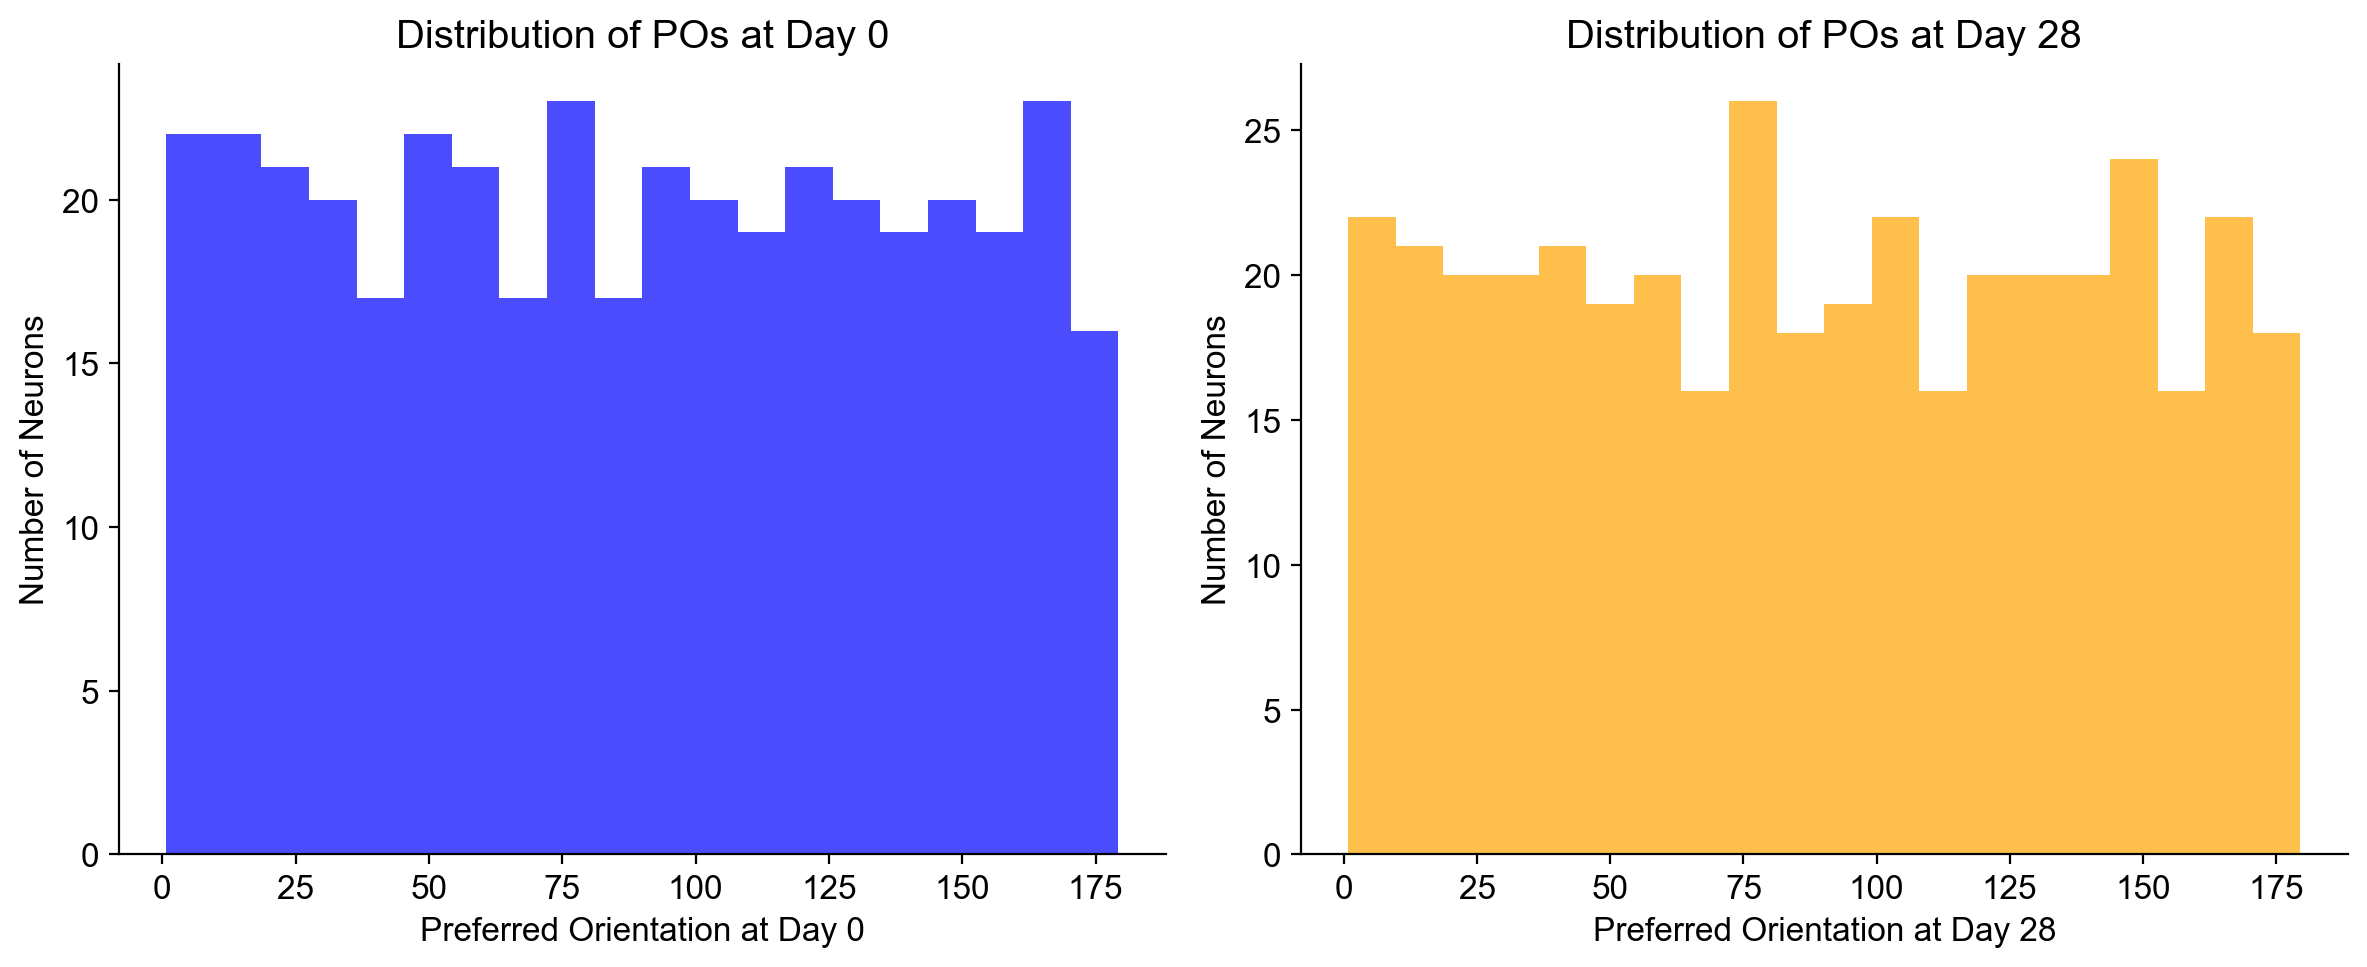

In [10]:
# Plot POs at day 0 and day 28
plt.figure(figsize=(12, 5), dpi=200)
plt.subplot(1, 2, 1)
plt.hist(net.POs[0], bins=20, color='blue', alpha=0.7)
plt.xlabel('Preferred Orientation at Day 0')
plt.ylabel('Number of Neurons')
plt.title('Distribution of POs at Day 0')

plt.subplot(1, 2, 2)
plt.hist(net.POs[-1], bins=20, color='orange', alpha=0.7)
plt.xlabel('Preferred Orientation at Day 28')
plt.ylabel('Number of Neurons')
plt.title('Distribution of POs at Day 28')
plt.tight_layout()
plt.show()

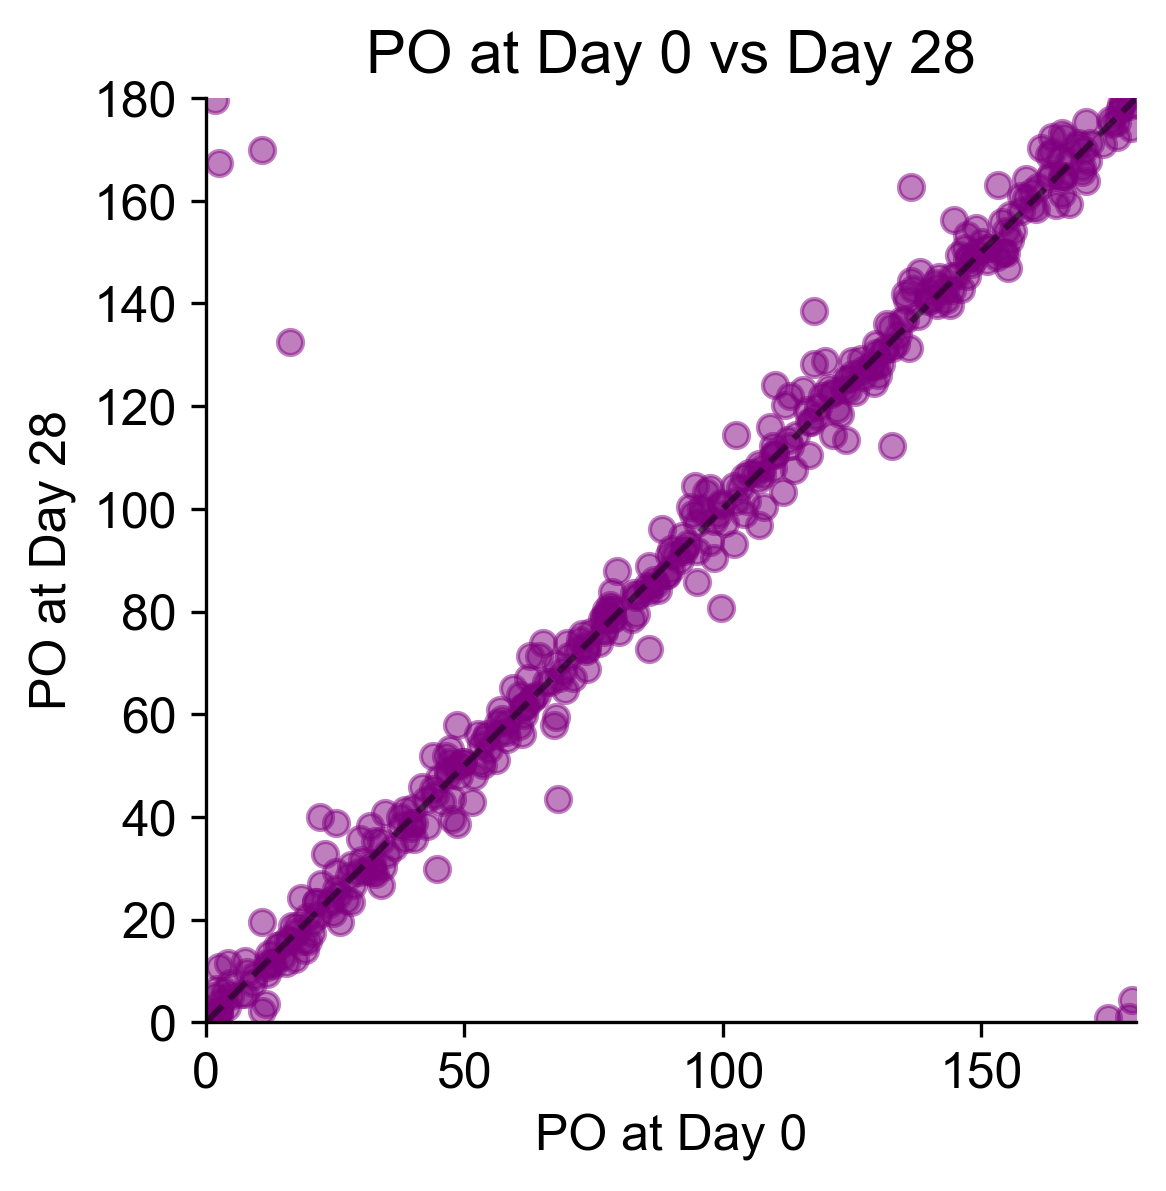

In [11]:
# Plot POs at day 0 vs day 28
plt.figure(figsize=(4, 4), dpi=300)
plt.scatter(net.POs[0], net.POs[-1], color='purple', alpha=0.5)
plt.xlabel('PO at Day 0')
plt.ylabel('PO at Day 28')
plt.title('PO at Day 0 vs Day 28')
plt.plot([0, 180], [0, 180], 'k--', alpha=0.5)  # Diagonal line for reference
plt.xlim(0, 180)
plt.ylim(0, 180)
plt.show()

In [12]:
# # to check how many neurons are masked at each day (i.e. have flat tuning curves)
# for day in [0, 7, 14, 28]:
#     tc = net.estimate_tuning_curves_at_day(day)
#     peak = np.max(tc, axis=1)
#     threshold = 0.05 * np.max(peak)
#     n_masked = np.sum(peak <= threshold)
#     print(f"Day {day}: {n_masked}/{net.N} neurons masked")

If the number masked grows over time (more neurons losing their tuning as weights diffuse), that confirms the variance is a measurement artifact from weight diffusion, not genuine drift heterogeneity. In that case, a more meaningful quantity to report would be the fraction of neurons that maintain stable tuning rather than drift magnitude averaged over all neurons including those that lost tuning.

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:711: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  if savefig:


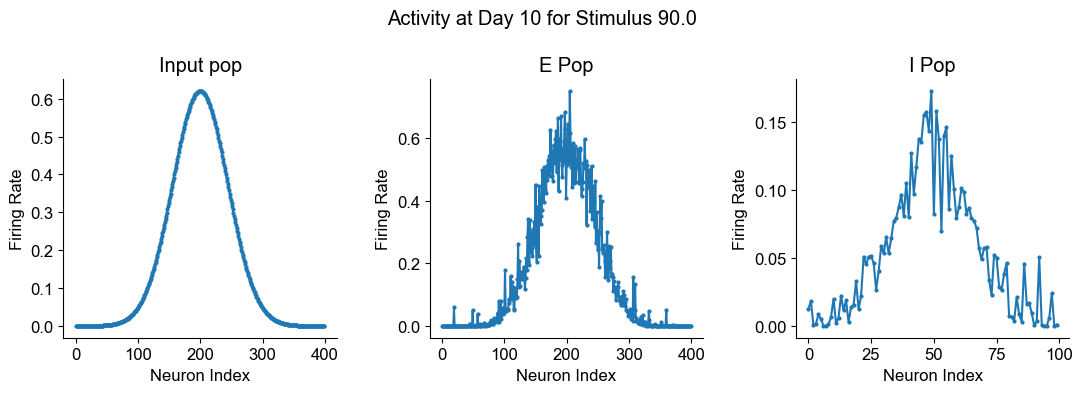

In [13]:
net.plot_activity_at_day(10, 90)

In [15]:
net.plot_population_tuning_curves(10)

 12%|█▏        | 58/500 [00:27<03:30,  2.10it/s]


KeyboardInterrupt: 

### Test time varying inh modualation

In [ ]:
net_varying_inh = BaselineNetwork()